<a href="https://colab.research.google.com/github/yuningrumzattayu/Pengembangan-Machine-Learning/blob/main/Analisis_Sentiment_menggunakan_SVM%2C_Naive_Bayes_dan_Logistic_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
pd.options.mode.chained_assignment = None
import numpy as np
seed = 0
np.random.seed(seed)
import matplotlib.pyplot as plt
import seaborn as sns
import csv
import requests
from io import StringIO
from sklearn.model_selection import train_test_split

In [ ]:
clean_df = pd.read_csv('data_cleaned.csv')

In [ ]:
clean_df = clean_df.dropna()
print("Jumlah Ulasan", clean_df.shape[0])

Jumlah Ulasan 12000


In [ ]:
sentiment = pd.get_dummies(clean_df['sentimen']).astype(int)
final_df = pd.concat([clean_df, sentiment], axis=1)
final_df = final_df.drop(columns='sentimen')
final_df

,reviews,text_clean,text_casefoldingText,text_slangwords,text_tokenizingText,text_stopword,text_akhir,polarity_score,polarity,sentimen_score,negative,neutral,positive
0,"Aplikasi sangat jelek, mengecewakan, sdh uppda...",Aplikasi sangat jelek mengecewakan sdh uppdate...,aplikasi sangat jelek mengecewakan sdh uppdate...,aplikasi sangat jelek mengecewakan sdh uppdate...,"['aplikasi', 'sangat', 'jelek', 'mengecewakan'...","['aplikasi', 'jelek', 'mengecewakan', 'sdh', '...",aplikasi jelek mengecewakan sdh uppdate aktifk...,-15,negative,-15,1,0,0
1,kalo ke aplikasi provider sendiri kasih data l...,kalo ke aplikasi provider sendiri kasih data l...,kalo ke aplikasi provider sendiri kasih data l...,kalau ke aplikasi provider sendiri kasih data ...,"['kalau', 'ke', 'aplikasi', 'provider', 'sendi...","['aplikasi', 'provider', 'kasih', 'data', 'bia...",aplikasi provider kasih data biar akses lahh d...,-20,negative,-20,1,0,0
2,Ini kenapa sih XL jaringannya jadi lemot bahka...,Ini kenapa sih XL jaringannya jadi lemot bahka...,ini kenapa sih xl jaringannya jadi lemot bahka...,ini kenapa sih xl jaringannya jadi lambat bahk...,"['ini', 'kenapa', 'sih', 'xl', 'jaringannya', ...","['xl', 'jaringannya', 'lambat', 'ilang²an', 's...",xl jaringannya lambat ilang²an salah kuota sek...,-8,negative,-8,1,0,0
3,gatau ya xl kok lemot banget ngisi paket di ap...,gatau ya xl kok lemot banget ngisi paket di ap...,gatau ya xl kok lemot banget ngisi paket di ap...,gatau iya xl kok lambat banget mengisi paket d...,"['gatau', 'iya', 'xl', 'kok', 'lambat', 'bange...","['gatau', 'xl', 'lambat', 'banget', 'mengisi',...",gatau xl lambat banget mengisi paket aplikasi ...,-11,negative,-11,1,0,0
4,Tidak ada pemberitahuan update mengenai fitur ...,Tidak ada pemberitahuan update mengenai fitur ...,tidak ada pemberitahuan update mengenai fitur ...,tidak ada pemberitahuan update mengenai fitur ...,"['tidak', 'ada', 'pemberitahuan', 'update', 'm...","['pemberitahuan', 'update', 'fitur', 'aplikasi...",pemberitahuan update fitur aplikasi tetiba fit...,-32,negative,-32,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
11995,bagus meskipun kecil kuota yg bisa internetan👍,bagus meskipun kecil kuota yg bisa internetan,bagus meskipun kecil kuota yg bisa internetan,bagus meskipun kecil kuota yang bisa internetan,"['bagus', 'meskipun', 'kecil', 'kuota', 'yang'...","['bagus', 'kuota', 'internetan']",bagus kuota internetan,-4,negative,-4,1,0,0
11996,Yang di perbaiki harusnya bukan sistem nya tp ...,Yang di perbaiki harusnya bukan sistem nya tp ...,yang di perbaiki harusnya bukan sistem nya tp ...,yang di perbaiki harusnya bukan sistem nya tap...,"['yang', 'di', 'perbaiki', 'harusnya', 'bukan'...","['perbaiki', 'sistem', 'developernya', 'aplika...",perbaiki sistem developernya aplikasi layak de...,-6,negative,-6,1,0,0
11997,kalo buka apk suka lemot. padahal sinyal full....,kalo buka apk suka lemot padahal sinyal full t...,kalo buka apk suka lemot padahal sinyal full t...,kalau buka aplikasi suka lambat padahal sinyal...,"['kalau', 'buka', 'aplikasi', 'suka', 'lambat'...","['buka', 'aplikasi', 'suka', 'lambat', 'sinyal...",buka aplikasi suka lambat sinyal full apa-apa ...,3,positive,3,0,0,1
11998,Xl tolong di perbaiki aplikasinya saya tidak b...,Xl tolong di perbaiki aplikasinya saya tidak b...,xl tolong di perbaiki aplikasinya saya tidak b...,xl tolong di perbaiki aplikasinya saya tidak b...,"['xl', 'tolong', 'di', 'perbaiki', 'aplikasiny...","['xl', 'tolong', 'perbaiki', 'aplikasinya', 'm...",xl tolong perbaiki aplikasinya mem buka xl men...,-2,negative,-2,1,0,0


### Pelabelan

In [ ]:
lexicon_positive = dict()

response = requests.get('https://raw.githubusercontent.com/angelmetanosaa/dataset/main/lexicon_positive.csv')

if response.status_code == 200:
    reader = csv.reader(StringIO(response.text), delimiter=',')

    for row in reader:
        lexicon_positive[row[0]] = int(row[1])

else:
    print("Failed to fetch positive lexicon data")

lexicon_negative = dict()

response = requests.get('https://raw.githubusercontent.com/angelmetanosaa/dataset/main/lexicon_negative.csv')

if response.status_code == 200:
    reader = csv.reader(StringIO(response.text), delimiter=',')

    for row in reader:
        lexicon_negative[row[0]] = int(row[1])
else:
    print("Failed to fetch negative lexicon data")

In [ ]:
def sentiment_analysis_lexicon_indonesia(text):
    score = 0
    for word in text.split():
        if (word in lexicon_positive):
            score = score + lexicon_positive[word]

    for word in text.split():
        if (word in lexicon_negative):
            score = score + lexicon_negative[word]

    polarity=''

    if (score > 0):
        polarity = 'positive'
    elif (score < 0):
        polarity = 'negative'
    else:
        polarity = 'neutral'

    return score, polarity

In [ ]:
results = clean_df['text_akhir'].apply(sentiment_analysis_lexicon_indonesia)
results = list(zip(*results))
clean_df['polarity_score'] = results[0]
clean_df['polarity'] = results[1]
print(clean_df['polarity'].value_counts())

polarity
negative    8671
positive    2772
neutral      557
Name: count, dtype: int64


polarity
negative    8671
positive    2772
neutral      557
Name: count, dtype: int64


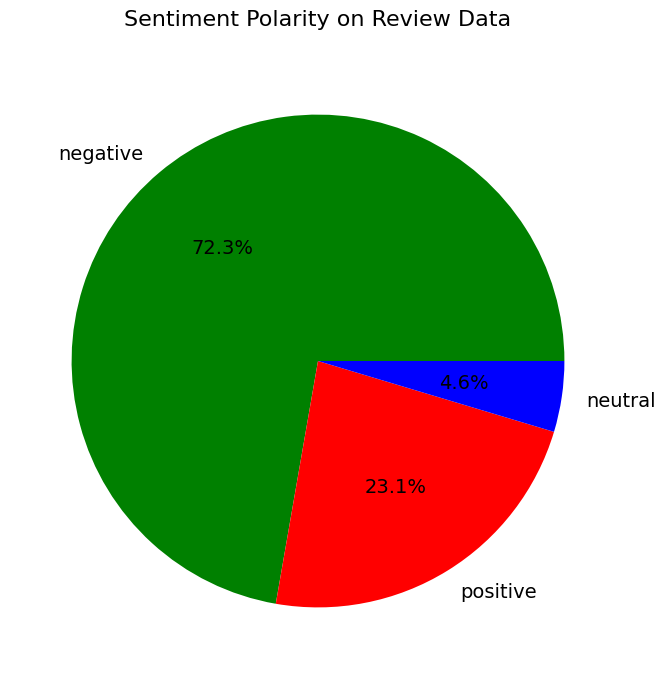

In [ ]:
import matplotlib.pyplot as plt

results = clean_df['text_akhir'].apply(sentiment_analysis_lexicon_indonesia)
results = list(zip(*results))
clean_df['polarity_score'] = results[0]
clean_df['polarity'] = results[1]

print(clean_df['polarity'].value_counts())

fig, ax = plt.subplots(figsize=(8, 8))

sizes = clean_df['polarity'].value_counts().values
labels = clean_df['polarity'].value_counts().index
colors = ['green', 'red', 'blue']

ax.pie(x=sizes, labels=labels, autopct='%1.1f%%', colors=colors, textprops={'fontsize': 14})

ax.set_title('Sentiment Polarity on Review Data', fontsize=16, pad=20)

plt.show()

In [ ]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.naive_bayes import BernoulliNB
from sklearn.metrics import accuracy_score, precision_score

### Data Splitting

In [ ]:
clean_df.head(2)

,reviews,text_clean,text_casefoldingText,text_slangwords,text_tokenizingText,text_stopword,text_akhir,polarity_score,polarity,sentimen_score,sentimen
0,"Aplikasi sangat jelek, mengecewakan, sdh uppda...",Aplikasi sangat jelek mengecewakan sdh uppdate...,aplikasi sangat jelek mengecewakan sdh uppdate...,aplikasi sangat jelek mengecewakan sdh uppdate...,"['aplikasi', 'sangat', 'jelek', 'mengecewakan'...","['aplikasi', 'jelek', 'mengecewakan', 'sdh', '...",aplikasi jelek mengecewakan sdh uppdate aktifk...,-15,negative,-15,negative
1,kalo ke aplikasi provider sendiri kasih data l...,kalo ke aplikasi provider sendiri kasih data l...,kalo ke aplikasi provider sendiri kasih data l...,kalau ke aplikasi provider sendiri kasih data ...,"['kalau', 'ke', 'aplikasi', 'provider', 'sendi...","['aplikasi', 'provider', 'kasih', 'data', 'bia...",aplikasi provider kasih data biar akses lahh d...,-20,negative,-20,negative


In [ ]:
# Pisahkan data menjadi fitur (tweet) dan label (sentimen)
X = clean_df['text_akhir']
y = clean_df['polarity']

In [ ]:
# Ekstraksi fitur dengan TF-IDF
tfidf = TfidfVectorizer(max_features=200, min_df=17, max_df=0.8 )
X_tfidf = tfidf.fit_transform(X)

In [ ]:
# Konversi hasil ekstraksi fitur menjadi dataframe
features_df = pd.DataFrame(X_tfidf.toarray(), columns=tfidf.get_feature_names_out())

# Menampilkan hasil ekstraksi fitur
features_df

,akses,aktif,akun,ambil,aneh,apknya,aplikasi,aplikasinya,app,autentikasi,...,uang,udh,ulang,update,utama,versi,voucher,wifi,xl,youtube
0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.284787,0.000000,0.0,0.0,...,0.0,0.000000,0.0,0.111015,0.0,0.000000,0.0,0.0,0.077662,0.0
1,0.436459,0.0,0.0,0.0,0.0,0.000000,0.232556,0.000000,0.0,0.0,...,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.0
2,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,...,0.0,0.252641,0.0,0.000000,0.0,0.000000,0.0,0.0,0.133706,0.0
3,0.000000,0.0,0.0,0.0,0.0,0.000000,0.345013,0.000000,0.0,0.0,...,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.0,0.250894,0.0
4,0.000000,0.0,0.0,0.0,0.0,0.000000,0.100679,0.000000,0.0,0.0,...,0.0,0.000000,0.0,0.156985,0.0,0.000000,0.0,0.0,0.000000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11995,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,...,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.0
11996,0.000000,0.0,0.0,0.0,0.0,0.000000,0.195664,0.000000,0.0,0.0,...,0.0,0.000000,0.0,0.000000,0.0,0.500684,0.0,0.0,0.000000,0.0
11997,0.000000,0.0,0.0,0.0,0.0,0.000000,0.159009,0.000000,0.0,0.0,...,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.0,0.173447,0.0
11998,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.483676,0.0,0.0,...,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.0,0.289617,0.0


In [ ]:
# Bagi data menjadi data latih dan data uji
X_train, X_test, y_train, y_test = train_test_split(X_tfidf, y, test_size=0.2, random_state=42)

### Pemodelan Naive Bayes

In [ ]:
from sklearn.naive_bayes import BernoulliNB

# Membuat objek model Naive Bayes (Bernoulli Naive Bayes)
naive_bayes = BernoulliNB()

# Melatih model Naive Bayes pada data pelatihan
naive_bayes.fit(X_train.toarray(), y_train)

# Prediksi sentimen pada data pelatihan dan data uji
y_pred_train_nb = naive_bayes.predict(X_train.toarray())
y_pred_test_nb = naive_bayes.predict(X_test.toarray())

# Evaluasi akurasi model Naive Bayes
accuracy_train_nb = accuracy_score(y_pred_train_nb, y_train)
accuracy_test_nb = accuracy_score(y_pred_test_nb, y_test)

# Menampilkan akurasi
print('Naive Bayes - accuracy_train:', accuracy_train_nb)
print('Naive Bayes - accuracy_test:', accuracy_test_nb)

Naive Bayes - accuracy_train: 0.8115625
Naive Bayes - accuracy_test: 0.8033333333333333


### Pemodelan Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression

# Membuat objek model Logistic Regression
logistic_regression = LogisticRegression()

# Melatih model Logistic Regression pada data pelatihan
logistic_regression.fit(X_train.toarray(), y_train)

# Prediksi sentimen pada data pelatihan dan data uji
y_pred_train_lr = logistic_regression.predict(X_train.toarray())
y_pred_test_lr = logistic_regression.predict(X_test.toarray())

# Evaluasi akurasi model Logistic Regression pada data pelatihan
accuracy_train_lr = accuracy_score(y_pred_train_lr, y_train)

# Evaluasi akurasi model Logistic Regression pada data uji
accuracy_test_lr = accuracy_score(y_pred_test_lr, y_test)

# Menampilkan akurasi
print('Logistic Regression - accuracy_train:', accuracy_train_lr)
print('Logistic Regression - accuracy_test:', accuracy_test_lr)

Logistic Regression - accuracy_train: 0.8702083333333334
Logistic Regression - accuracy_test: 0.8554166666666667


### Pemodelan SVM

In [ ]:
from sklearn.svm import SVC

# Membuat objek model SVM
svm = SVC(kernel='linear')

# Melatih model SVM pada data pelatihan
svm.fit(X_train, y_train)

# Prediksi sentimen pada data uji
y_pred_test_svm = svm.predict(X_test)

# Evaluasi akurasi model SVM pada data uji
accuracy_test_svm = accuracy_score(y_test, y_pred_test_svm)

# Prediksi sentimen pada data latih
y_pred_train_svm = svm.predict(X_train)

# Evaluasi akurasi model SVM pada data latih
accuracy_train_svm = accuracy_score(y_train, y_pred_train_svm)

# Menampilkan akurasi
print('SVM - accuracy_train:', accuracy_train_svm)
print('SVM - accuracy_test:', accuracy_test_svm)

SVM - accuracy_train: 0.8704166666666666
SVM - accuracy_test: 0.8558333333333333


In [ ]:
import pandas as pd

results_df = pd.DataFrame({
    'Model': ['Naive Bayes','Logistic Regression', 'Support Vector Machine'],
    'Accuracy Train': [accuracy_train_nb, accuracy_train_lr, accuracy_train_svm],
    'Accuracy Test': [accuracy_test_nb, accuracy_test_lr, accuracy_test_svm]
})
# Menampilkan hanya kolom "Accuracy Test"
accuracy_test_only = results_df[['Model', 'Accuracy Test']]
print(accuracy_test_only)

                    Model  Accuracy Test
0             Naive Bayes       0.803333
1     Logistic Regression       0.855417
2  Support Vector Machine       0.855833


In [ ]:
accuracy_test_sorted = accuracy_test_only.sort_values(by='Accuracy Test', ascending=False)

print(accuracy_test_sorted)

                    Model  Accuracy Test
2  Support Vector Machine       0.855833
1     Logistic Regression       0.855417
0             Naive Bayes       0.803333


In [ ]:
!pip install pipreqs

  Preparing metadata (setup.py) ... done
  Using cached jedi-0.19.1-py2.py3-none-any.whl.metadata (22 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 798.3/798.3 kB 14.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 257.4/257.4 kB 16.0 MB/s eta 0:00:00
Using cached jedi-0.19.1-py2.py3-none-any.whl (1.6 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.0/48.0 kB 2.9 MB/s eta 0:00:00
  Created wheel for docopt: filename=docopt-0.6.2-py2.py3-none-any.whl size=13704 sha256=4c06b79db58735254e8a5fd9cf90a373ee0056a2b444902ee94599c9e8108148
  Stored in directory: /root/.cache/pip/wheels/fc/ab/d4/5da2067ac95b36618c629a5f93f809425700506f72c9732fac
Successfully built docopt
  Attempting uninstall: mistune
    Found existing installation: mistune 0.8.4
    Uninstalling mistune-0.8.4:
      Successfully uninstalled mistune-0.8.4
  Attempting uninstall: ipython
    Found existing installation: ipython 7.34.0
    Uninstalling ipython-7.34.0:
      Successfully uninstalled ipython-7.34